# Cardiac Dataset Profiling: Complexity and Fairness Characteristics

Summarize dataset difficulty, representation balance, and pre-processing fairness from existing profile JSONs.

## 1. Setup and imports
Load the libraries and define shared plotting styles.

In [1]:
from __future__ import annotations
from pathlib import Path
import sys
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ROOT_DIR = Path.cwd().resolve()
if (ROOT_DIR / "configs").exists() is False:
    ROOT_DIR = ROOT_DIR.parents[0]
sys.path.append(str(ROOT_DIR / "src"))

from fairxai.notebook_utils import (
    load_domain_config,
    get_relevant_datasets,
    make_figure_path_builder,
 )
from fairxai.viz import PALETTE_DATASET, PALETTE_SEX
from fairxai.notebook_utils.profiling import (
    find_profile_files,
    load_profiles,
    dataset_overview_rows,
    sensitive_distribution_rows,
    plot_sensitive_proportions,
    representation_balance_rows,
    plot_balance_cv,
    plot_size_ratio_heatmap,
    group_statistics_rows,
    plot_prevalence_heatmap_by_age,
    plot_prevalence_by_sex,
    spd_rows,
    plot_spd_bars,
    positive_rate_rows,
    plot_positive_rates_by_age,
 )

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")

## 2. Configuration and paths
Resolve project paths and locate profiling outputs.

In [2]:
MEDICAL_AREA = "cardiac"
NOTEBOOK_TYPE = "profiling"
SAVE_FIGURES = True

cfg = load_domain_config(ROOT_DIR, MEDICAL_AREA)
schema_cfg = cfg["schema_cfg"]

RESULTS_DIR = ROOT_DIR / "results" / MEDICAL_AREA
PROFILE_GLOB = "*_data_profile.json"
DATASETS = get_relevant_datasets(schema_cfg, MEDICAL_AREA)
FIGURES_DIR, fig_path = make_figure_path_builder(ROOT_DIR, MEDICAL_AREA, NOTEBOOK_TYPE)

RESULTS_DIR

PosixPath('/home/miguel/Desktop/Dissertacao/Code/FairXAI/results/cardiac')

## 3. Load existing profiles
Read pre-computed profiling JSON files (one per dataset).

In [3]:
profile_files = find_profile_files(RESULTS_DIR, PROFILE_GLOB, DATASETS)
profile_files

{'cleveland': PosixPath('/home/miguel/Desktop/Dissertacao/Code/FairXAI/results/cardiac/profiling/cleveland_data_profile.json'),
 'kaggle_heart': PosixPath('/home/miguel/Desktop/Dissertacao/Code/FairXAI/results/cardiac/profiling/kaggle_heart_data_profile.json'),
 'cardio70k': PosixPath('/home/miguel/Desktop/Dissertacao/Code/FairXAI/results/cardiac/profiling/cardio70k_data_profile.json')}

In [4]:
profiles = load_profiles(profile_files)
missing = [name for name in DATASETS if name not in profiles]
print("Loaded profiles:", sorted(profiles.keys()))
if missing:
    print("Missing profiles:", missing)

Loaded profiles: ['cardio70k', 'cleveland', 'kaggle_heart']


---
# Section 1: Basic dataset characteristics
---

## 4. Dataset overview table
Extract sample size, feature count, and target prevalence.

In [5]:
overview_df = dataset_overview_rows(profiles, DATASETS)
overview_df

,dataset,samples,features,target_prevalence
0,cleveland,297,17,0.461279
1,kaggle_heart,918,15,0.553377
2,cardio70k,70000,15,0.499700


## 5. Sensitive attribute distributions
Summarize age-group and sex counts with underrepresented groups (<10%).

In [6]:
sensitive_df = sensitive_distribution_rows(profiles, DATASETS, ["age_group", "sex"])
sensitive_df

,dataset,attribute,group,count,pct,underrepresented
0,cleveland,age_group,50-59,126,0.424242,False
1,cleveland,age_group,40-49,75,0.252525,False
2,cleveland,age_group,60-69,73,0.245791,False
3,cleveland,age_group,<40,17,0.057239,True
4,cleveland,age_group,70+,6,0.020202,True
5,cleveland,sex,1,201,0.676768,False
6,cleveland,sex,0,96,0.323232,False
7,kaggle_heart,age_group,50-59,381,0.415033,False
8,kaggle_heart,age_group,40-49,223,0.242919,False
9,kaggle_heart,age_group,60-69,197,0.214597,False


### Visualization: sensitive attribute proportions
Stacked bar charts for age groups and sex.

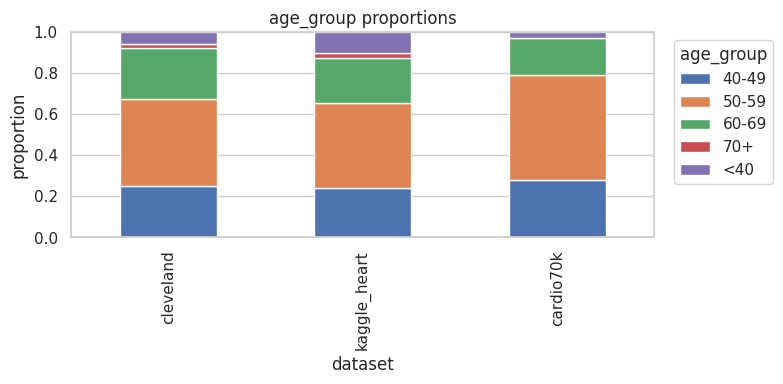

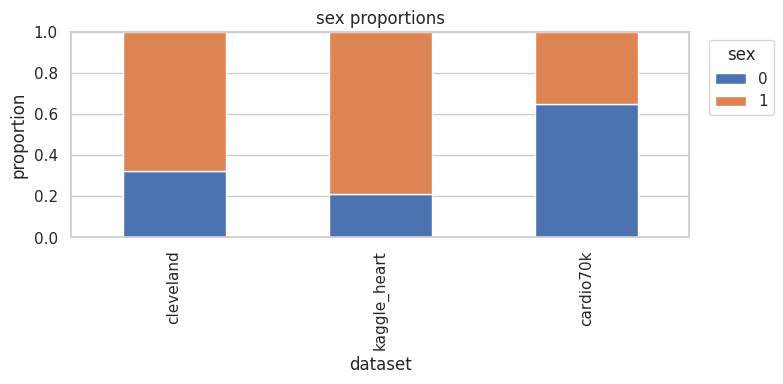

In [7]:
def plot_sensitive_proportions(df: pd.DataFrame, attribute: str) -> None:
    subset = df[df["attribute"] == attribute].copy()
    if subset.empty:
        print(f"No data for {attribute}")
        return
    pivot = subset.pivot_table(index="dataset", columns="group", values="pct", aggfunc="sum").fillna(0)
    pivot = pivot.reindex(DATASETS)
    ax = pivot.plot(kind="bar", stacked=True, figsize=(8, 4))
    ax.set_title(f"{attribute} proportions")
    ax.set_ylabel("proportion")
    ax.set_ylim(0, 1.0)
    ax.legend(title=attribute, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()

plot_sensitive_proportions(sensitive_df, "age_group")
plot_sensitive_proportions(sensitive_df, "sex")

plot_sensitive_proportions(sensitive_df, "age_group", DATASETS)
plot_sensitive_proportions(sensitive_df, "sex", DATASETS)

## 6. Coefficient of variation (CV)
Lower CV means more balanced representation across groups.

In [8]:
def extract_representation_balance(profile: dict, attribute: str) -> dict:
    return profile.get("representation_balance", {}).get(attribute, {})

balance_rows = []
for name in DATASETS:
    profile = profiles.get(name, {})
    for attr in ["age_group", "sex"]:
        stats = extract_representation_balance(profile, attr)
        balance_rows.append({
            "dataset": name,
            "attribute": attr,
            "cv": stats.get("cv"),
            "min_group": stats.get("min_group_size"),
            "max_group": stats.get("max_group_size"),
            "size_ratio": stats.get("size_ratio"),
        })

balance_df = pd.DataFrame(balance_rows)
balance_df

,dataset,attribute,cv,min_group,max_group,size_ratio
0,cleveland,age_group,None,6,126,21.000000
1,cleveland,sex,None,96,201,2.093750
2,kaggle_heart,age_group,None,24,381,15.875000
3,kaggle_heart,sex,None,193,725,3.756477
4,cardio70k,age_group,None,1896,35556,18.753165
5,cardio70k,sex,None,24470,45530,1.860646


balance_df = representation_balance_rows(profiles, DATASETS, ["age_group", "sex"])
balance_df

In [9]:
plot_df = balance_df.dropna(subset=["cv"]).copy()
if plot_df.empty:
    print("No representation balance data available.")
else:
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.barplot(data=plot_df, x="dataset", y="cv", hue="attribute", ax=ax)
    ax.axhline(0.3, color="#999999", linestyle="--", linewidth=1)
    ax.axhline(0.7, color="#999999", linestyle=":", linewidth=1)
    ax.set_title("Representation balance (CV)")
    ax.set_ylabel("CV")
    ax.set_ylim(0, max(0.8, plot_df["cv"].max() * 1.2))
    ax.legend(title="attribute", loc="upper right")
    plt.tight_layout()

No representation balance data available.


plot_balance_cv(balance_df)

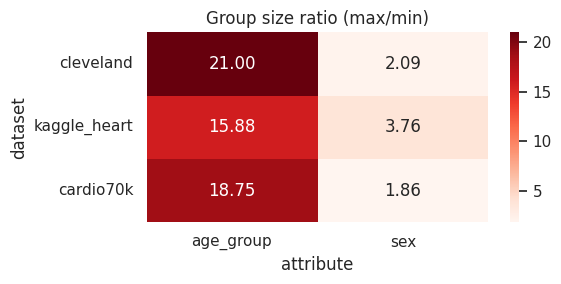

In [10]:
ratio_df = balance_df.dropna(subset=["size_ratio"]).copy()
if ratio_df.empty:
    print("No size ratio data available.")
else:
    heat = ratio_df.pivot(index="dataset", columns="attribute", values="size_ratio").reindex(DATASETS)
    fig, ax = plt.subplots(figsize=(6, 3))
    sns.heatmap(heat, annot=True, fmt=".2f", cmap="Reds", ax=ax)
    ax.set_title("Group size ratio (max/min)")
    plt.tight_layout()

plot_size_ratio_heatmap(balance_df, DATASETS)

## 8. Target prevalence by demographic groups
Group-level prevalence across age groups and sex.

In [11]:
def extract_group_stats(profile: dict, attribute: str) -> list[dict]:
    stats = profile.get("group_statistics", {}).get(attribute, [])
    if isinstance(stats, dict):
        stats = [stats]
    return stats or []

group_rows = []
for name in DATASETS:
    profile = profiles.get(name, {})
    for attr in ["age_group", "sex"]:
        for entry in extract_group_stats(profile, attr):
            group_rows.append({
                "dataset": name,
                "attribute": attr,
                "group": entry.get("group") or entry.get("name"),
                "n": entry.get("count") or entry.get("n"),
                "prevalence": entry.get("prevalence") or entry.get("positive_rate"),
            })

group_df = pd.DataFrame(group_rows)
group_df

,dataset,attribute,group,n,prevalence
0,cleveland,age_group,None,None,None
1,cleveland,sex,None,None,None
2,kaggle_heart,age_group,None,None,None
3,kaggle_heart,sex,None,None,None
4,cardio70k,age_group,None,None,None
5,cardio70k,sex,None,None,None


group_df = group_statistics_rows(profiles, DATASETS, ["age_group", "sex"])
group_df

TypeError: Image data of dtype object cannot be converted to float

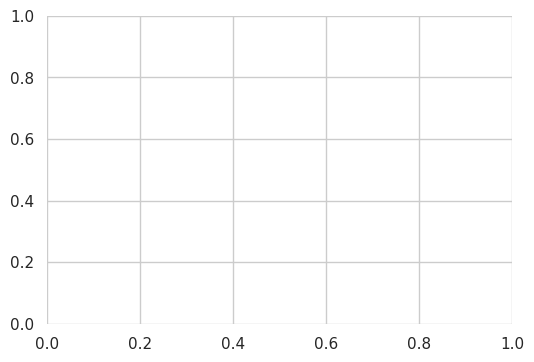

In [12]:
age_df = group_df[group_df["attribute"] == "age_group"].copy()
if age_df.empty:
    print("No age-group prevalence data available.")
else:
    age_order = ["<40", "40-49", "50-59", "60-69", "70+"]
    age_df["group"] = pd.Categorical(age_df["group"], categories=age_order, ordered=True)
    heat = age_df.pivot(index="group", columns="dataset", values="prevalence").reindex(age_order)
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.heatmap(heat, annot=True, fmt=".2f", cmap="coolwarm", vmin=0, vmax=1, ax=ax)
    ax.set_title("Prevalence by age group")
    ax.set_xlabel("dataset")
    ax.set_ylabel("age_group")
    plt.tight_layout()

age_order = ["<40", "40-49", "50-59", "60-69", "70+"]
plot_prevalence_heatmap_by_age(group_df, age_order)

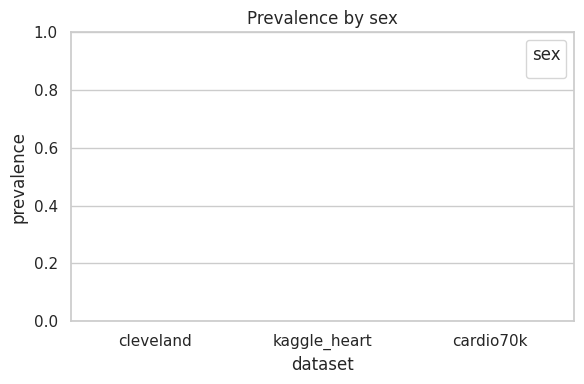

In [ ]:
sex_df = group_df[group_df["attribute"] == "sex"].copy()
if sex_df.empty:
    print("No sex prevalence data available.")
else:
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.barplot(data=sex_df, x="dataset", y="prevalence", hue="group", ax=ax, palette=PALETTE_SEX)
    ax.set_title("Prevalence by sex")
    ax.set_ylabel("prevalence")
    ax.set_ylim(0, 1.0)
    ax.legend(title="sex", loc="upper right")
    plt.tight_layout()

plot_prevalence_by_sex(group_df)

In [ ]:
def compute_spd_from_rates(rates: dict) -> float | None:
    if not rates:
        return None
    vals = [v for v in rates.values() if v is not None]
    if len(vals) < 2:
        return None
    return float(max(vals) - min(vals))

spd_rows = []
for name in DATASETS:
    profile = profiles.get(name, {})
    spd_info = profile.get("label_imbalance_by_group", {}).get("statistical_parity_difference", {})
    for attr in ["age_group", "sex"]:
        value = spd_info.get(attr) if isinstance(spd_info, dict) else None
        if isinstance(value, dict):
            spd_value = value.get("max_spd") or value.get("spd") or compute_spd_from_rates(value.get("rates", {}))
            max_ratio = value.get("max_ratio")
        else:
            spd_value = value
            max_ratio = None
        spd_rows.append({
            "dataset": name,
            "attribute": attr,
            "max_spd": spd_value,
            "max_ratio": max_ratio,
        })

spd_df = pd.DataFrame(spd_rows)
spd_df

,dataset,attribute,max_spd,max_ratio
0,cleveland,age_group,None,None
1,cleveland,sex,None,None
2,kaggle_heart,age_group,None,None
3,kaggle_heart,sex,None,None
4,cardio70k,age_group,None,None
5,cardio70k,sex,None,None


spd_df = spd_rows(profiles, DATASETS, ["age_group", "sex"])
spd_df

In [ ]:
plot_spd = spd_df.dropna(subset=["max_spd"]).copy()
if plot_spd.empty:
    print("No SPD data available.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    sns.barplot(data=plot_spd, x="dataset", y="max_spd", hue="attribute", ax=axes[0])
    axes[0].axhline(0.1, color="#999999", linestyle="--", linewidth=1)
    axes[0].set_title("Max SPD")
    axes[0].set_ylim(0, max(0.2, plot_spd["max_spd"].max() * 1.2))
    if plot_spd["max_ratio"].notna().any():
        sns.barplot(data=plot_spd.dropna(subset=["max_ratio"]), x="dataset", y="max_ratio", hue="attribute", ax=axes[1])
        axes[1].set_title("Max ratio")
    else:
        axes[1].axis("off")
    for ax in axes:
        ax.legend(title="attribute", loc="upper right")
    plt.tight_layout()

No SPD data available.


plot_spd_bars(spd_df)

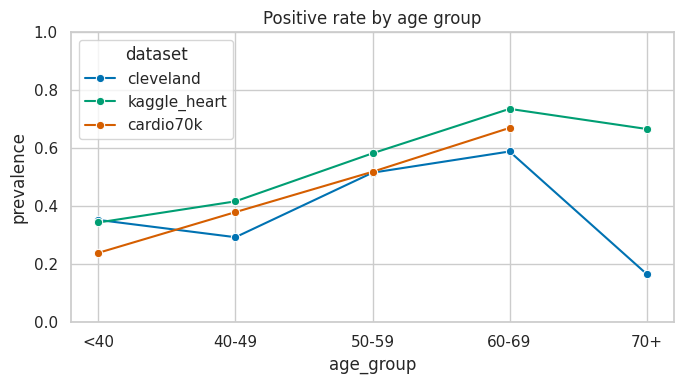

In [ ]:
rates_df = positive_rate_rows(profiles, DATASETS, "age_group")
plot_positive_rates_by_age(rates_df, ["<40", "40-49", "50-59", "60-69", "70+"])